#### Importing the libraies and datasets

In [105]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models,saving
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [81]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

#### Exploring the Dataset

In [82]:
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"\nNumber of training samples: {x_train.shape[0]}")
print(f"Number of test samples: {x_test.shape[0]}")
print(f"Image dimensions: {x_train.shape[1]} x {x_train.shape[2]}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Number of training samples: 60000
Number of test samples: 10000
Image dimensions: 28 x 28


#### Visualize the dataset

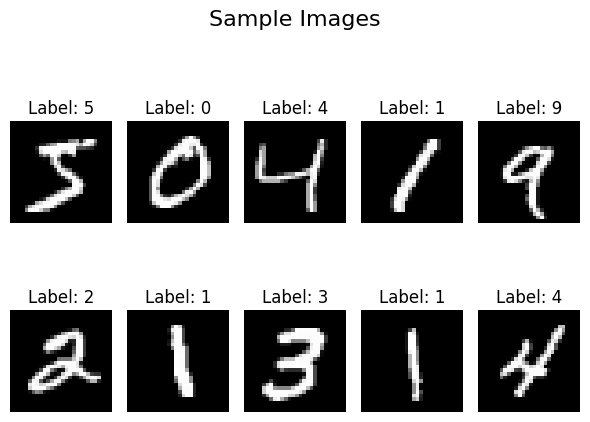

In [83]:
fig, axes = plt.subplots(2, 5, figsize=(6, 5))
fig.suptitle('Sample Images', fontsize=16)

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

##### Step 2 : PreProcess the Data

In [84]:
# Normalize pixel values to range [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Reshape images to (28, 28, 1) for CNN input
x_train_norm = x_train_norm.reshape(-1, 28, 28, 1)
x_test_norm = x_test_norm.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoded format
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print("Data preprocessing completed!")
print(f"Training data shape after reshaping: {x_train_norm.shape}")
print(f"Test data shape after reshaping: {x_test_norm.shape}")
print(f"Training labels shape after encoding: {y_train_encoded.shape}")
print(f"Test labels shape after encoding: {y_test_encoded.shape}")
print(f"\nSample normalized pixel value range: [{x_train_norm.min()}, {x_test_norm.max()}]")
print(f"Sample one-hot encoded label: {y_train_encoded[0]} (Original label: {y_train[0]})")

Data preprocessing completed!
Training data shape after reshaping: (60000, 28, 28, 1)
Test data shape after reshaping: (10000, 28, 28, 1)
Training labels shape after encoding: (60000, 10)
Test labels shape after encoding: (10000, 10)

Sample normalized pixel value range: [0.0, 1.0]
Sample one-hot encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] (Original label: 5)


In [85]:
# Split test data into validation and test sets (50-50 split)
x_val, x_test_final, y_val, y_test_final = train_test_split(
    x_test_norm,
    y_test_encoded,
    test_size=0.5,
    random_state=42
)

print("\nData Split Summary:")
print("="*60)
print(f"Training data shape:   {x_train_norm.shape}")
print(f"Validation data shape: {x_val.shape}")
print(f"Test data shape:       {x_test_final.shape}")
print(f"\nTraining labels shape:   {y_train_encoded.shape}")
print(f"Validation labels shape: {y_val.shape}")
print(f"Test labels shape:       {y_test_final.shape}")
print("="*60)


Data Split Summary:
Training data shape:   (60000, 28, 28, 1)
Validation data shape: (5000, 28, 28, 1)
Test data shape:       (5000, 28, 28, 1)

Training labels shape:   (60000, 10)
Validation labels shape: (5000, 10)
Test labels shape:       (5000, 10)


#### CNN Model Building

In [86]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Dropout to prevent overfitting
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
]
)

In [87]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,162 (973.29 KB)

 Trainable params: 249,162 (973.29 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
#Model Complie
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [89]:
# Train the model with validation split
history = model.fit(
    x_train_norm,
    y_train_encoded,
    batch_size=128,
    epochs=10,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 103ms/step - accuracy: 0.8761 - loss: 0.3983 - val_accuracy: 0.9816 - val_loss: 0.0562
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.9729 - loss: 0.1038 - val_accuracy: 0.9886 - val_loss: 0.0384
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.9804 - loss: 0.0750 - val_accuracy: 0.9902 - val_loss: 0.0342
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.9846 - loss: 0.0575 - val_accuracy: 0.9912 - val_loss: 0.0279
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.9879 - loss: 0.0481 - val_accuracy: 0.9914 - val_loss: 0.0364
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 104ms/step - accuracy: 0.9892 - loss: 0.0404 - val_accuracy: 0.9914 - val_loss: 0.0289
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.9907 - loss: 0.0355 - val_accuracy: 0.9924 - val_loss: 0.0305
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - accuracy: 0.9916 - loss: 0

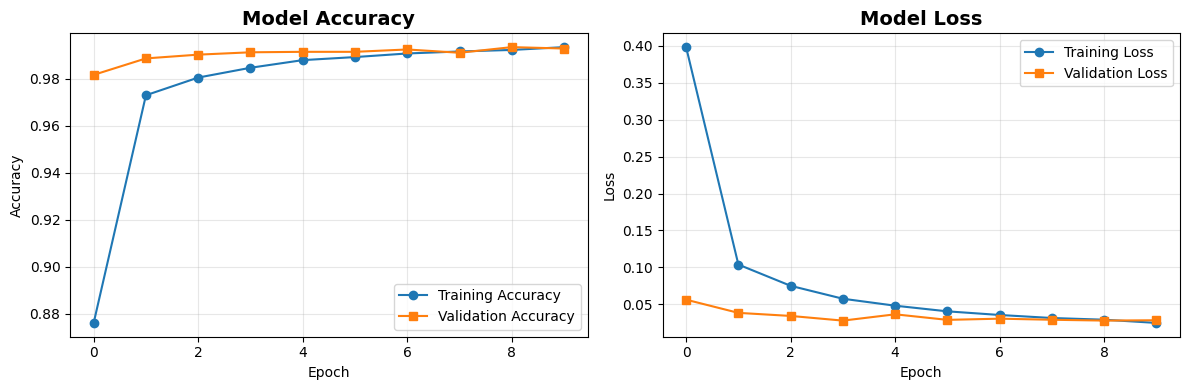

In [90]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [91]:
# Evaluating the data
test_loss, test_accuracy = model.evaluate(x_test_final, y_test_final, verbose=0)

print("Model Evaluation Result")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Model Evaluation Result
Test Loss: 0.0264
Test Accuracy: 99.26%


#### Prediction Using test Data

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


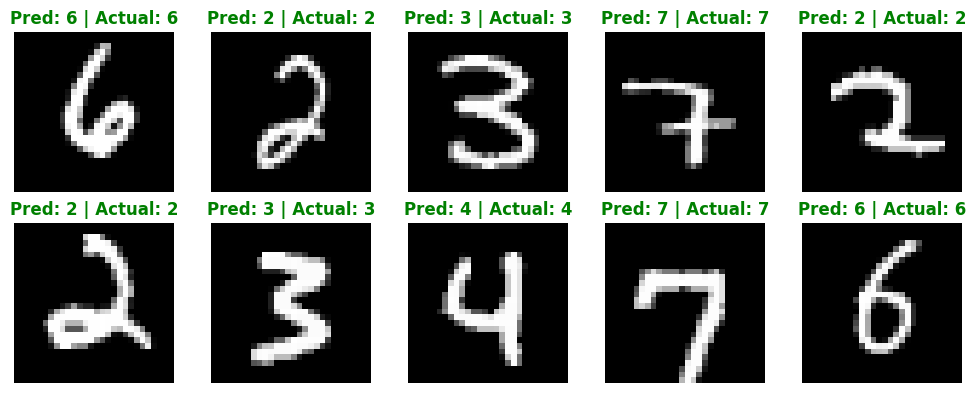

In [92]:
# Generate predictions on final test set
predictions = model.predict(x_test_final)
predicted_classes = np.argmax(predictions, axis=1)
# Convert one-hot encoded back to labels for comparison
y_test_labels = np.argmax(y_test_final, axis=1)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    # Get original test image index for visualization
    ax.imshow(x_test_final[i].reshape(28, 28), cmap='gray')
    predicted = predicted_classes[i]
    actual = y_test_labels[i]
    # Color code: green for correct, red for incorrect
    color = 'green' if predicted == actual else 'red'
    ax.set_title(f'Pred: {predicted} | Actual: {actual}', color=color, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

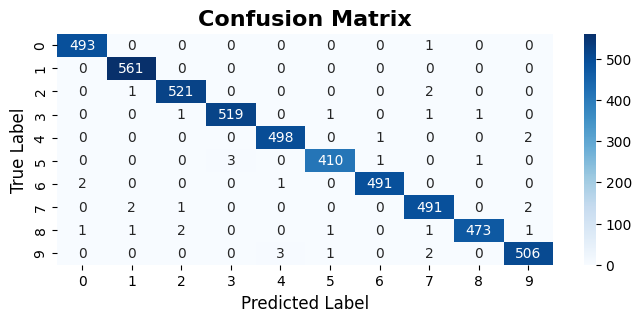


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       494
           1       0.99      1.00      1.00       561
           2       0.99      0.99      0.99       524
           3       0.99      0.99      0.99       523
           4       0.99      0.99      0.99       501
           5       0.99      0.99      0.99       415
           6       1.00      0.99      0.99       494
           7       0.99      0.99      0.99       496
           8       1.00      0.99      0.99       480
           9       0.99      0.99      0.99       512

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



In [93]:
# Confusion Matrix
cm = confusion_matrix(y_test_labels, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_labels, predicted_classes))

#### Testing th model with custom images

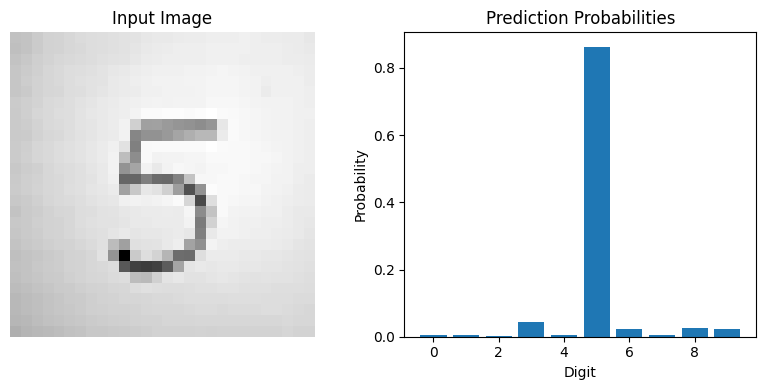

Predicted Digit: 5


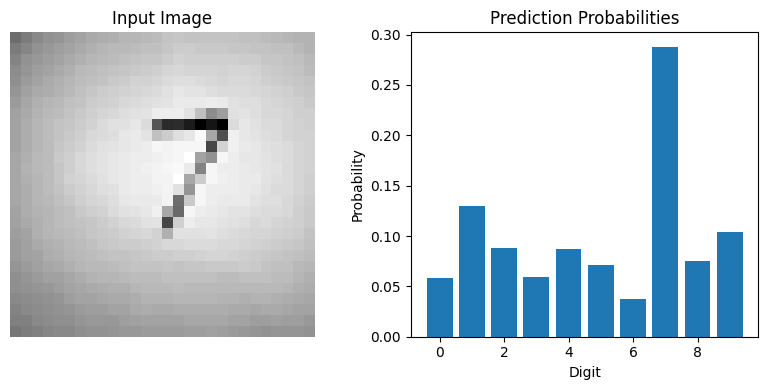

Predicted Digit: 7


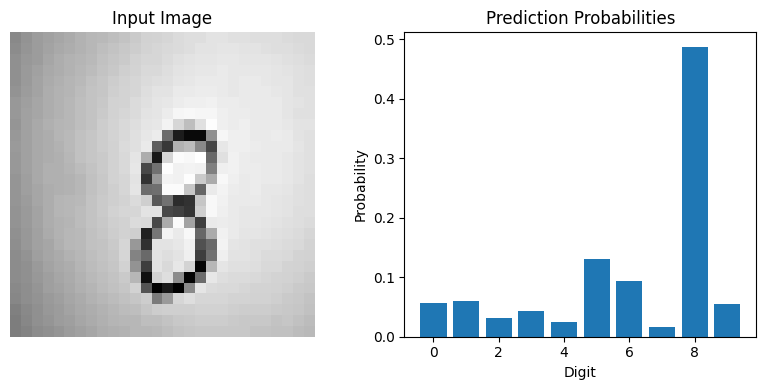

Predicted Digit: 8


In [109]:
def predict_custom_image(image_path, model):
    processed_img, original_img = preprocess_custom_image(image_path)
    prediction = model.predict(processed_img, verbose=0)
    predicted_digit = np.argmax(prediction)

    # Show image + probability graph
    plt.figure(figsize=(8, 4))

    # Input image
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title('Input Image')
    plt.axis('off')

    # Probability graph
    plt.subplot(1, 2, 2)
    plt.bar(range(10), prediction[0])
    plt.title('Prediction Probabilities')
    plt.xlabel('Digit')
    plt.ylabel('Probability')

    plt.tight_layout()
    plt.show()

    print(f"Predicted Digit: {predicted_digit}")

    return predicted_digit, confidence


folder_path = r"/content/CNN Test Images"

valid_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.gif']
image_files = [f for f in os.listdir(folder_path)
               if os.path.splitext(f)[1].lower() in valid_extensions]

for img_file in image_files:
    img_path = os.path.join(folder_path, img_file)
    predict_custom_image(img_path, model)

####Save the Model

In [111]:
model.save('cnn_model.h5')
keras.saving.save_model(model, 'cnn_model.keras')

###Summary of Prediction

 This CNN model is designed with multiple layers to recognize patterns in handwritten digits. It starts with convolutional layers that extract features like edges and shapes, followed by pooling layers to reduce image size and complexity. The extracted features are then flattened and fed into dense layers, which make final decisions. To prevent overfitting, dropout layers were included. Finally, an output layer classifies the digit, giving probability for each number.

During custom image testing, the Convolutional Neural Network model successfully processed and predicted digits from several handwritten images. For instance, the model identified '5' from 'Test2.jpg', '7' from 'Test3.jpg', and '8' from 'Test1.jpg'. These results highlight the model's capability to generalize beyond the MNIST dataset, though prediction accuracy remains reliant on the clarity of the input images, effective preprocessing, and the resemblance of the custom handwriting to the training data.

